# B4 - Ordonnancement industriel (RCPSP)

Le Resource-Constrained Project Scheduling Problem (RCPSP) est le problème de référence en ordonnancement sous contraintes de ressources. Il consiste à planifier un ensemble de tâches avec des contraintes de précédence et des ressources renouvelables limitées de manière à minimiser le makespan.

## 1. Extraction des données PSPLIB
Les archives `.tar` (j30.sm, j60.sm, j90.sm.tar, j120.sm.tar) sont extraites automatiquement si elles sont présentes dans le dossier `data/`.

In [1]:
import os
import tarfile

def extract_psplib_data():
    data_dir = 'data'
    archives = {
        'j30': 'j30.sm',
        'j60': 'j60.sm',
        'j90': 'j90.sm.tar',
        'j120': 'j120.sm.tar'
    }
    
    for name, filename in archives.items():
        tar_path = os.path.join(data_dir, filename)
        extract_path = os.path.join(data_dir, name)
        
        if os.path.exists(tar_path) and not os.path.exists(extract_path):
            print(f"Extraction de {tar_path} vers {extract_path}...")
            os.makedirs(extract_path, exist_ok=True)
            with tarfile.open(tar_path) as tar:
                tar.extractall(path=extract_path)
        elif os.path.exists(extract_path):
            print(f"Les données {name} sont déjà extraites dans {extract_path}")
        else:
            print(f"Archive introuvable : {tar_path}")

extract_psplib_data()

Extraction de data/j30.sm vers data/j30...
Extraction de data/j60.sm vers data/j60...
Extraction de data/j90.sm.tar vers data/j90...
Extraction de data/j120.sm.tar vers data/j120...


## 2. Parseur de données PSPLIB

In [2]:
import re

def parse_sm_file(file_path):
    """
    Parses a PSPLIB .sm file for the single-mode RCPSP.
    """
    with open(file_path, 'r') as f:
        lines = f.readlines()
        
    jobs = 0
    num_renewable = 0
    horizon = 0
    precedences = {}
    durations = {}
    requests = {}
    capacities = []
    mode = None
    
    for i, line in enumerate(lines):
        line = line.strip()
        if not line or line.startswith('*') or line.startswith('---'):
            continue
        if line.startswith('jobs (incl. supersource/sink )'):
            jobs = int(re.search(r'\d+', line).group())
            continue
        if line.startswith('- renewable'):
            num_renewable = int(re.search(r'\d+', line).group())
            continue
        if line.startswith('horizon'):
            horizon = int(re.search(r'\d+', line).group())
            continue
        if line.startswith('PRECEDENCE RELATIONS:'):
            mode = 'PRECEDENCE'
            continue
        if line.startswith('REQUESTS/DURATIONS:'):
            mode = 'REQUESTS'
            continue
        if line.startswith('RESOURCEAVAILABILITIES:'):
            mode = 'CAPACITIES'
            continue
            
        if mode == 'PRECEDENCE':
            if line.startswith('jobnr.') or line.startswith('jobnr'): continue
            parts = [int(x) for x in line.split()]
            if len(parts) >= 3:
                job_id = parts[0]
                successors = parts[3:]
                precedences[job_id] = successors
        elif mode == 'REQUESTS':
            if line.startswith('jobnr.') or line.startswith('jobnr') or line.startswith('----------------'): continue
            parts = [int(x) for x in line.split()]
            if len(parts) >= 3:
                job_id = parts[0]
                durations[job_id] = parts[2]
                requests[job_id] = parts[3:]
        elif mode == 'CAPACITIES':
            if line.startswith('R 1') or line.startswith('R'): continue
            parts = [int(x) for x in line.split()]
            if len(parts) > 0:
                capacities = parts
                mode = None
                
    return {
        'jobs': jobs,
        'num_renewable': num_renewable,
        'horizon': horizon,
        'precedences': precedences,
        'durations': durations,
        'requests': requests,
        'capacities': capacities
    }

parsed_data = parse_sm_file("data/j30/j301_1.sm")
print(f"Parsed jobs: {parsed_data['jobs']}, Horizon: {parsed_data['horizon']}")

Parsed jobs: 32, Horizon: 158


## 3. Visualisation de l'ordonnancement

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_gantt_chart(schedule, title="RCPSP Gantt Chart"):
    fig, ax = plt.subplots(figsize=(10, 6))
    sorted_jobs = sorted(schedule.items(), key=lambda x: (x[1]['start'], x[0]))
    
    yticks = []
    yticklabels = []
    
    for i, (job_id, times) in enumerate(sorted_jobs):
        start = times['start']
        end = times['end']
        duration = end - start
        
        rect = patches.Rectangle((start, i - 0.4), duration, 0.8, facecolor='skyblue', edgecolor='black')
        ax.add_patch(rect)
        ax.text(start + duration / 2, i, str(job_id), ha='center', va='center', color='black', fontsize=10)
        
        yticks.append(i)
        yticklabels.append(f'Job {job_id}')
        
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)
    
    max_time = max(times['end'] for times in schedule.values()) if schedule else 0
    ax.set_xlim(0, max_time + 5)
    ax.set_ylim(-1, len(sorted_jobs))
    ax.set_xlabel("Time")
    ax.set_ylabel("Jobs")
    ax.set_title(title)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## 4. Modèle exact (CP-SAT)

CP-SAT Status: OPTIMAL
CP-SAT Makespan: 43.0


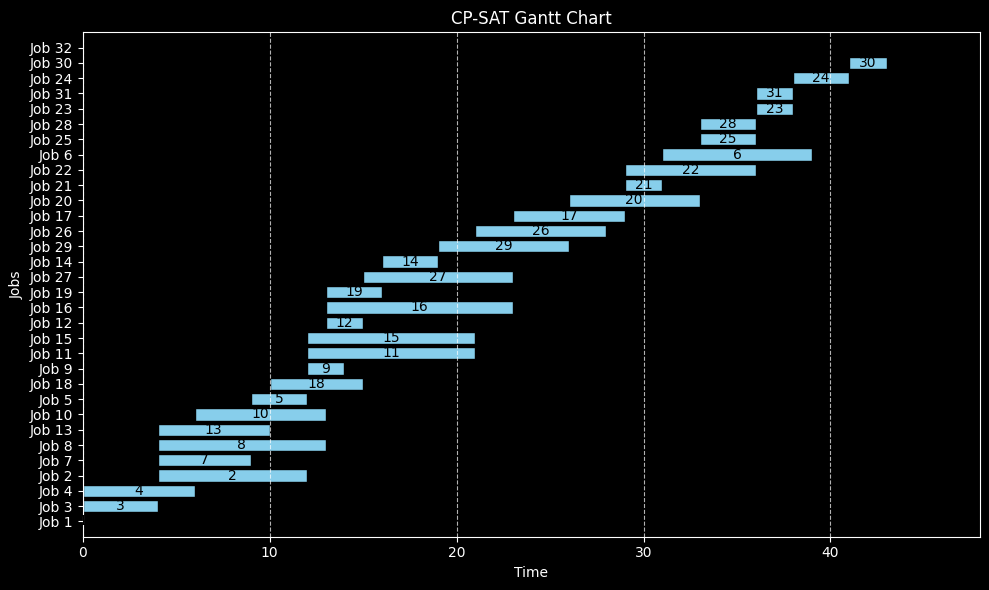

In [4]:
from ortools.sat.python import cp_model

def solve_rcpsp(parsed_data, max_time_seconds=60):
    model = cp_model.CpModel()
    
    jobs = parsed_data['jobs']
    horizon = parsed_data['horizon']
    precedences = parsed_data['precedences']
    durations = parsed_data['durations']
    requests = parsed_data['requests']
    capacities = parsed_data['capacities']
    num_renewable = parsed_data['num_renewable']
    
    tasks = {}
    starts = {}
    ends = {}
    
    for j in range(1, jobs + 1):
        duration = durations[j]
        start_var = model.NewIntVar(0, horizon, f'start_{j}')
        end_var = model.NewIntVar(0, horizon, f'end_{j}')
        interval_var = model.NewIntervalVar(start_var, duration, end_var, f'task_{j}')
        
        starts[j] = start_var
        ends[j] = end_var
        tasks[j] = interval_var
        
    for j, successors in precedences.items():
        for succ in successors:
            model.Add(starts[succ] >= ends[j])
            
    for r in range(num_renewable):
        intervals = []
        demands = []
        for j in range(1, jobs + 1):
            req = requests[j][r]
            if req > 0:
                intervals.append(tasks[j])
                demands.append(req)
        model.AddCumulative(intervals, demands, capacities[r])
        
    makespan = model.NewIntVar(0, horizon, 'makespan')
    model.Add(makespan == ends[jobs])
    model.Minimize(makespan)
    
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = max_time_seconds
    status = solver.Solve(model)
    
    result = {
        'status': status,
        'status_string': solver.StatusName(status),
        'makespan': None,
        'schedule': {}
    }
    
    if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
        result['makespan'] = solver.ObjectiveValue()
        for j in range(1, jobs + 1):
            result['schedule'][j] = {
                'start': solver.Value(starts[j]),
                'end': solver.Value(ends[j])
            }
    return result, solver

result_cp, solver = solve_rcpsp(parsed_data, max_time_seconds=10)
print(f"CP-SAT Status: {result_cp['status_string']}")
if result_cp['makespan'] is not None:
    print(f"CP-SAT Makespan: {result_cp['makespan']}")
    plot_gantt_chart(result_cp['schedule'], title="CP-SAT Gantt Chart")

## 5. Métaheuristique: Algorithme Génétique (Baseline)

GA Makespan: 43


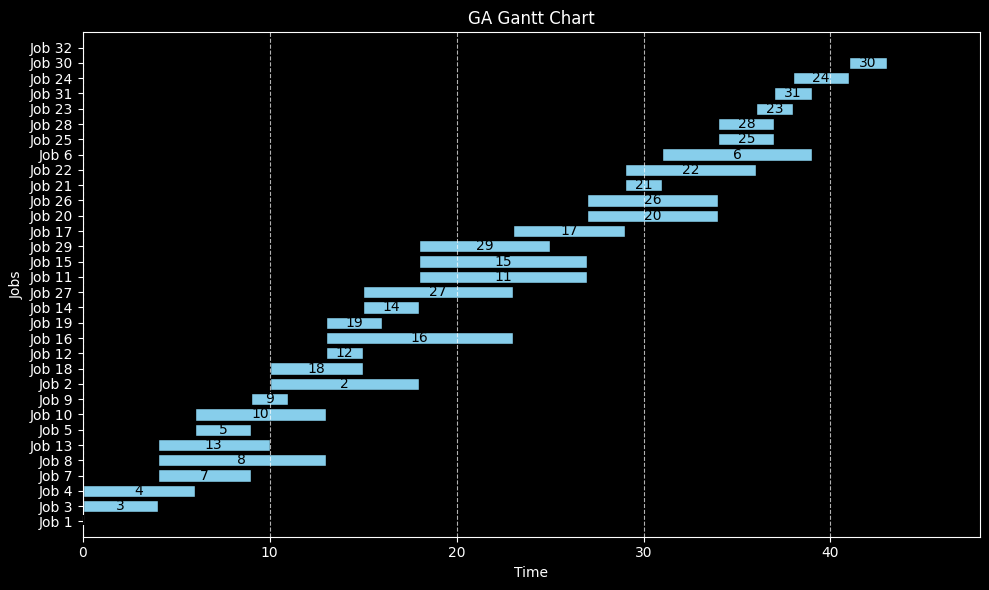

In [5]:
import random

def build_predecessors(precedences, num_jobs):
    preds = {i: set() for i in range(1, num_jobs + 1)}
    for u, succs in precedences.items():
        for v in succs:
            preds[v].add(u)
    return preds

def serial_sgs(permutation, parsed_data):
    jobs = parsed_data['jobs']
    durations = parsed_data['durations']
    requests = parsed_data['requests']
    capacities = parsed_data['capacities']
    num_renewable = parsed_data['num_renewable']
    precedences = parsed_data['precedences']
    preds = build_predecessors(precedences, jobs)
    
    schedule = {}
    horizon = parsed_data['horizon']
    profile = [[c for c in capacities] for _ in range(horizon + 1)]
    
    for job in permutation:
        duration = durations[job]
        reqs = requests[job]
        
        est = 0
        for p in preds[job]:
            if p in schedule:
                est = max(est, schedule[p]['end'])
                
        t = est
        while t + duration <= horizon:
            feasible = True
            for dt in range(duration):
                for r in range(num_renewable):
                    if profile[t + dt][r] < reqs[r]:
                        feasible = False
                        break
                if not feasible:
                    break
            if feasible:
                schedule[job] = {'start': t, 'end': t + duration}
                for dt in range(duration):
                    for r in range(num_renewable):
                        profile[t + dt][r] -= reqs[r]
                break
            t += 1
            
    makespan = max((s['end'] for s in schedule.values()), default=0)
    return makespan, schedule

def generate_random_feasible_permutation(jobs, preds):
    permutation = []
    ready = [j for j in range(1, jobs + 1) if not preds[j]]
    unscheduled = set(range(1, jobs + 1))
    
    while unscheduled:
        if not ready:
            break
        job = random.choice(ready)
        ready.remove(job)
        permutation.append(job)
        unscheduled.remove(job)
        
        for cand in unscheduled:
            if cand not in ready and all(p not in unscheduled for p in preds[cand]):
                ready.append(cand)
    return permutation

def solve_ga(parsed_data, pop_size=50, generations=100):
    jobs = parsed_data['jobs']
    preds = build_predecessors(parsed_data['precedences'], jobs)
    population = [generate_random_feasible_permutation(jobs, preds) for _ in range(pop_size)]
    
    best_makespan = float('inf')
    best_schedule = None
    
    for gen in range(generations):
        fitnesses = []
        for ind in population:
            makespan, schedule = serial_sgs(ind, parsed_data)
            fitnesses.append((makespan, ind, schedule))
            if makespan < best_makespan:
                best_makespan = makespan
                best_schedule = schedule
                
        fitnesses.sort(key=lambda x: x[0])
        new_population = [x[1] for x in fitnesses[:pop_size//2]]
        
        while len(new_population) < pop_size:
            new_population.append(generate_random_feasible_permutation(jobs, preds))
        population = new_population
        
    return best_makespan, best_schedule

makespan_ga, schedule_ga = solve_ga(parsed_data, pop_size=50, generations=100)
print(f"GA Makespan: {makespan_ga}")
plot_gantt_chart(schedule_ga, title="GA Gantt Chart")